<a href="https://colab.research.google.com/github/aayushchourasia123/Machine-Learning/blob/main/function%20transformer/Function_transfromer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

import scipy.stats as stats
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [23]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [24]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [25]:
df.fillna({'Age': df['Age'].mean()}, inplace=True)

In [26]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [27]:
x=df.iloc[:,1:3]
y=df.iloc[:,0]

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

Q. Why plot=plt is needed in stats.probplot() but not in sns.histplot()?

Ans. Seaborn is built on top of Matplotlib, and it automatically creates or uses the current plot (plt.gca()) behind the scenes.

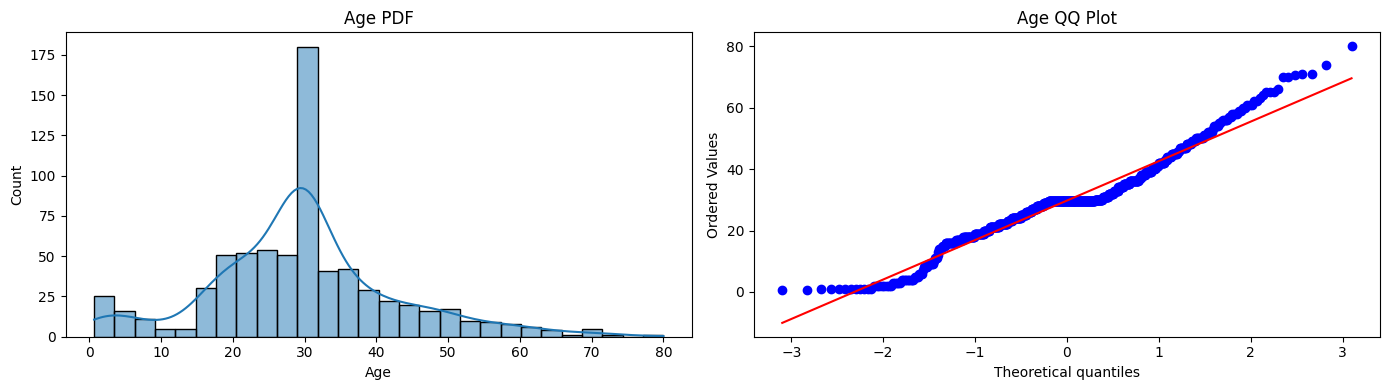

In [29]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(x_train['Age'],kde=True)
plt.title('Age PDF')

plt.subplot(1,2,2)
stats.probplot(x_train['Age'], dist="norm", plot=plt) #plot=plt tells it to draw the QQ plot on the current Matplotlib figure/axes using matplotlib.pyplot
plt.title('Age QQ Plot')

plt.tight_layout()
plt.show()

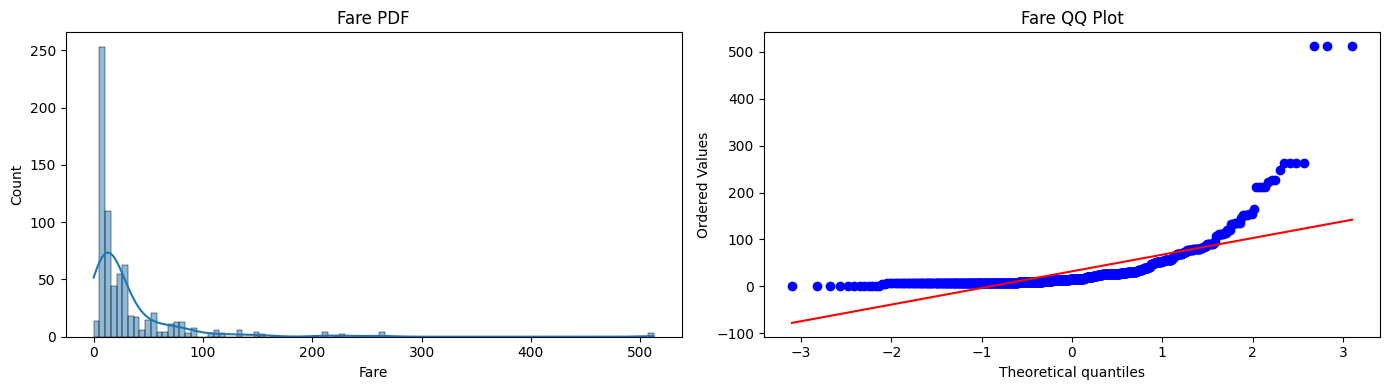

In [30]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(x_train['Fare'],kde=True)
plt.title('Fare PDF')

plt.subplot(1,2,2)
stats.probplot(x_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.tight_layout()
plt.show()


In [31]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [32]:
#without functiontranformer
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred=clf.predict(x_test)
y_pred2=clf2.predict(x_test)

print('accuracy of lr', accuracy_score(y_test,y_pred))
print('accuracy of dt', accuracy_score(y_test,y_pred2))

accuracy of lr 0.6983240223463687
accuracy of dt 0.6703910614525139


numpy.log and numpy.log1p are both functions in the NumPy library used for calculating logarithms

np.log1p= This function calculates the natural logarithm of (1 + x)

np.log= This function calculates the natural logarithm (base e) of x

use Handling Zeroes:
While np.log would result in an error or inf for an input of 0, np.log1p(0) correctly evaluates to 0, which is log(1). This makes log1p useful when your data might contain zero values and you want to apply a logarithmic transformation without encountering errors or needing to add a small constant manually.


In [33]:
#with functiontransformer
trf=FunctionTransformer(np.log1p)

In [34]:
x_train_transformed=trf.fit_transform(x_train)
x_test_transformed=trf.transform(x_test)

In [35]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)

y_pred=clf.predict(x_test_transformed)
y_pred2=clf2.predict(x_test_transformed)

#after applying function transformation logistic regression accuracy improved where as deciontree classifier accuracy remains same
#Decision tree classifiers are relatively insensitive to feature scaling and transformations, unlike some other machine learning algorithms
print('accuracy of lr', accuracy_score(y_test,y_pred))
print('accuracy of dt', accuracy_score(y_test,y_pred2))

accuracy of lr 0.7039106145251397
accuracy of dt 0.6759776536312849


In [36]:
#cross validation
x_transform=trf.fit_transform(x)

clf=LogisticRegression()
clf2=DecisionTreeClassifier()

print('LR',np.mean(cross_val_score(clf,x_transform,y,cv=10,scoring='accuracy')))
print('DT',np.mean(cross_val_score(clf2,x_transform,y,cv=10,scoring='accuracy')))

LR 0.678027465667915
DT 0.655505617977528


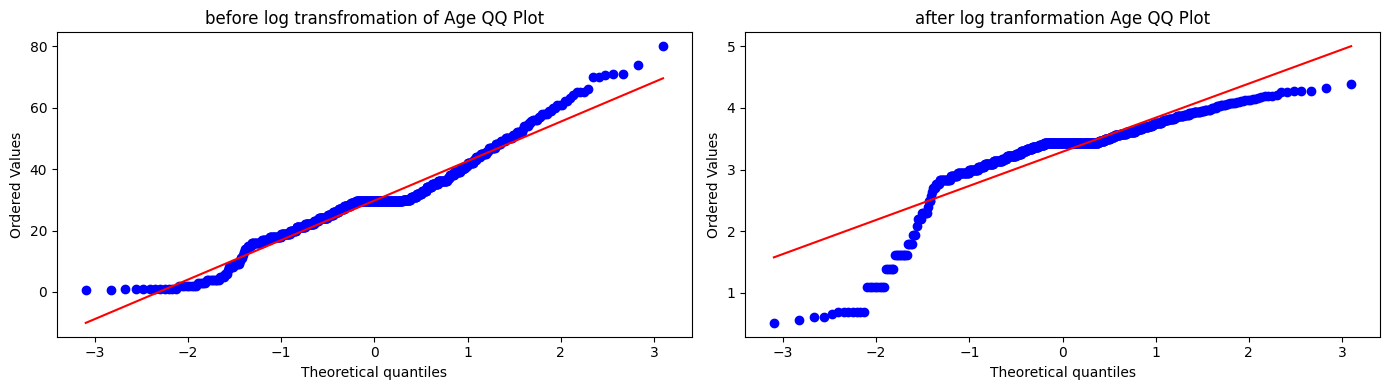

In [37]:
#before and after log transformation graph
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
stats.probplot(x_train['Age'], dist="norm", plot=plt)
plt.title('before log transfromation of Age QQ Plot')

plt.subplot(1,2,2)
stats.probplot(x_train_transformed['Age'], dist="norm", plot=plt)
plt.title('after log tranformation Age QQ Plot')

#age was not right skewed so after transformation this lead to a distribution that is less normal than the original data
plt.tight_layout()
plt.show()

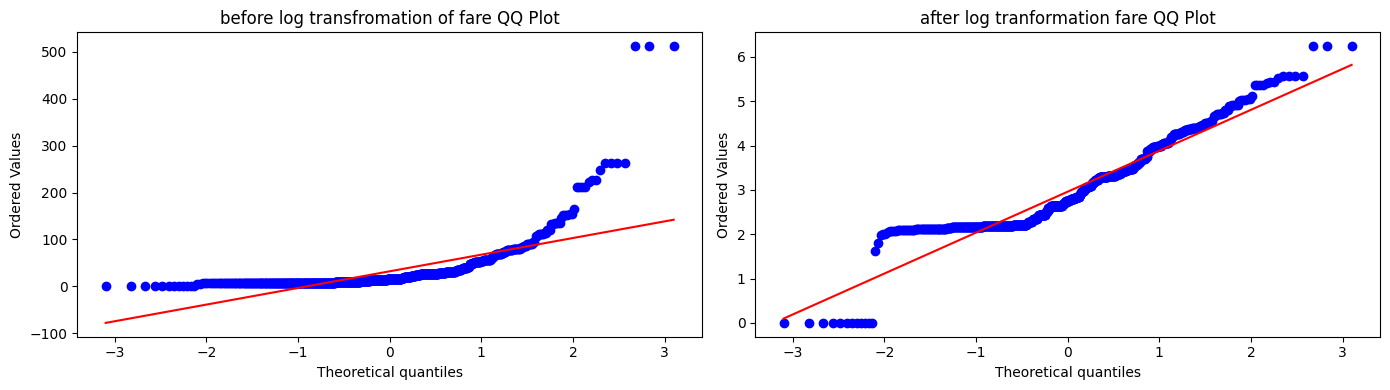

In [38]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
stats.probplot(x_train['Fare'], dist="norm", plot=plt)
plt.title('before log transfromation of fare QQ Plot')

plt.subplot(1,2,2)
stats.probplot(x_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('after log tranformation fare QQ Plot')

#fare was right skewed so after transformation this lead to a distribution that is more normal than the original data
plt.tight_layout()
plt.show()

In [39]:
from math import remainder
#custom transformer(on fare only) like sqrt,1/x etc
def apply_tranform(transform):
  x=df.iloc[:,1:3]
  y=df.iloc[:,0]

  trf=ColumnTransformer([('tf',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
  x_trans=trf.fit_transform(x)

  clf=LogisticRegression()

  print('accuracy',np.mean(cross_val_score(clf,x_trans,y,cv=10,scoring='accuracy')))

  plt.figure(figsize=(14,4))

  plt.subplot(1,2,1)
  stats.probplot(x['Fare'], dist="norm", plot=plt)
  plt.title('fare before transformation')

  plt.subplot(1,2,2)
  stats.probplot(x_trans[:,0], dist="norm", plot=plt)
  plt.title('fare after transformation')

  plt.tight_layout()
  plt.show()


accuracy 0.6431335830212235


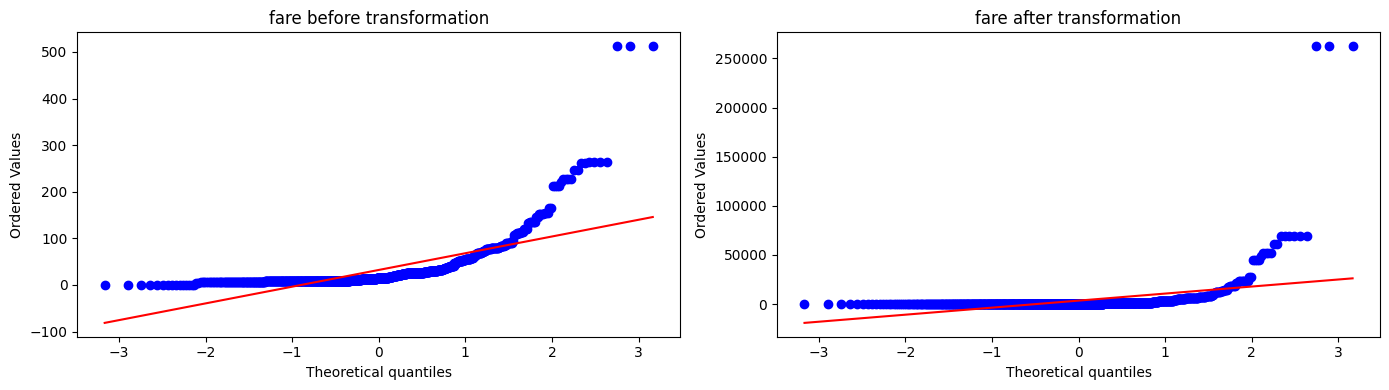

In [21]:
apply_tranform(lambda x: x**2)